In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = "data/MovieLens-1M"
users = pd.read_csv(f"{path}/users.csv")
ratings = pd.read_csv(f"{path}/ratings.csv")
movies = pd.read_csv(f"{path}/movies.csv")

In [3]:
ratings.head()

,user_id,movie_id,user_rating,timestamp
0,130,3107,5.0,977432193
1,3829,2114,4.0,965932967
2,1265,256,1.0,1012103552
3,2896,1389,5.0,972004605
4,5264,3635,4.0,961180111


In [4]:
movies.head()

,movie_id,movie_title,movie_genres,poster_url
0,3107,Backdraft (1991),"0, 7",https://image.tmdb.org/t/p/w500/bymJtYNIdiAiBR...
1,2114,"Outsiders, The (1983)",7,https://image.tmdb.org/t/p/w500/pl8Tf36TAOb2i5...
2,256,Junior (1994),"4, 15",https://image.tmdb.org/t/p/w500/4tRF43CbEYHmV8...
3,1389,Jaws 3-D (1983),"0, 10",https://image.tmdb.org/t/p/w500/kqDXj53F9paqVG...
4,3635,"Spy Who Loved Me, The (1977)",0,https://image.tmdb.org/t/p/w500/3ZxHKFxMYvAko6...


#### EDA

poster_url есть некоторые пропущенные, можно для удобства добавить картинку что нет url

In [5]:
users.info()
ratings.info()
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                6040 non-null   int64  
 1   user_gender            6040 non-null   bool   
 2   bucketized_user_age    6040 non-null   float64
 3   user_occupation_label  6040 non-null   int64  
 4   user_occupation_text   6040 non-null   str    
 5   user_zip_code          6040 non-null   str    
dtypes: bool(1), float64(1), int64(2), str(2)
memory usage: 242.0 KB
<class 'pandas.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   user_id      1000209 non-null  int64  
 1   movie_id     1000209 non-null  int64  
 2   user_rating  1000209 non-null  float64
 3   timestamp    1000209 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 30.5 MB
<cla

большинство пользователей оценили только маленькую часть всех доступных фильмов

In [6]:
sparsity = 1 - len(ratings) / (ratings.user_id.nunique() * ratings.movie_id.nunique())
sparsity

0.9553163743776871

average ratings per user

In [7]:
ratings.groupby("user_id").size().mean()

np.float64(165.5975165562914)

Распределение рейтингов

Большинство ставят оценку около 4

<Axes: xlabel='user_rating', ylabel='Count'>

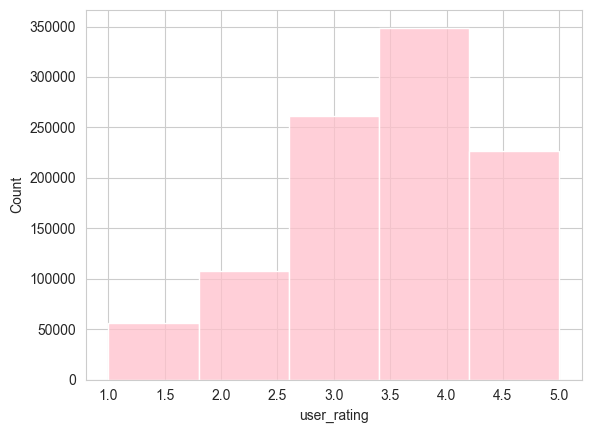

In [8]:
sns.histplot(ratings["user_rating"], bins=5, color='pink')

Распределение активности пользователей

Есть выбросы

<Axes: ylabel='Count'>

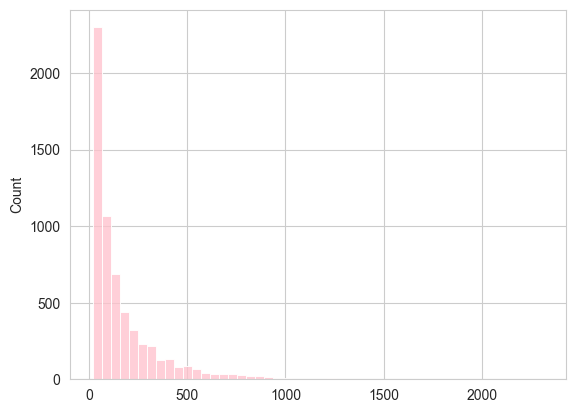

In [9]:
ratings_per_user = ratings.groupby("user_id").size()
sns.histplot(ratings_per_user, bins=50, color='pink')

Распределение популярности фильмов

Есть очень популярные фильмы

<Axes: ylabel='Count'>

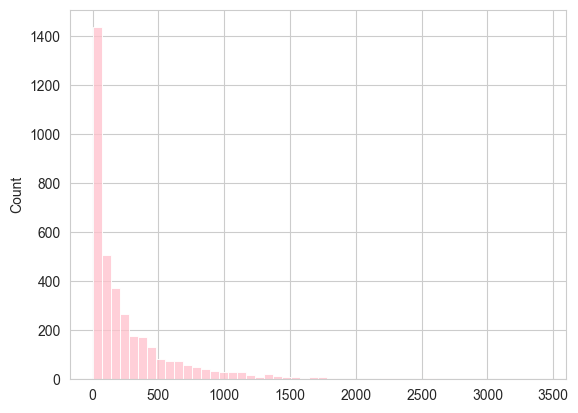

In [10]:
ratings_per_movie = ratings.groupby("movie_id").size()
sns.histplot(ratings_per_movie, bins=50, color='pink')

Проверка выбросов пользователей

Разброс оценок от 20 фильмов до 2314, нужно придумать как увеличить влияние малооцененных фильмов

In [11]:
ratings_per_user.describe()

count    6040.000000
mean      165.597517
std       192.747029
min        20.000000
25%        44.000000
50%        96.000000
75%       208.000000
max      2314.000000
dtype: float64

Проверка выбросов фильмов

Разброс оценок одного фильма от 1 до 3000, нужно придумать как увеличить влияние малооцененных фильмов

In [12]:
ratings_per_movie.describe()

count    3706.000000
mean      269.889099
std       384.047838
min         1.000000
25%        33.000000
50%       123.500000
75%       350.000000
max      3428.000000
dtype: float64

Есть перевес в сторону male гендера, при обучении лучше делать стратификацию по полу

<Axes: xlabel='user_gender', ylabel='count'>

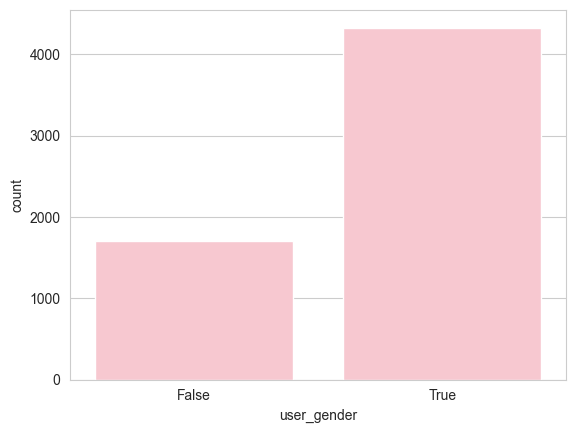

In [13]:
sns.countplot(x="user_gender", data=users, color='pink')

есть перевес по профессиям, так же лучше обратить на это внимание вдруг влияет

<Axes: xlabel='count', ylabel='user_occupation_text'>

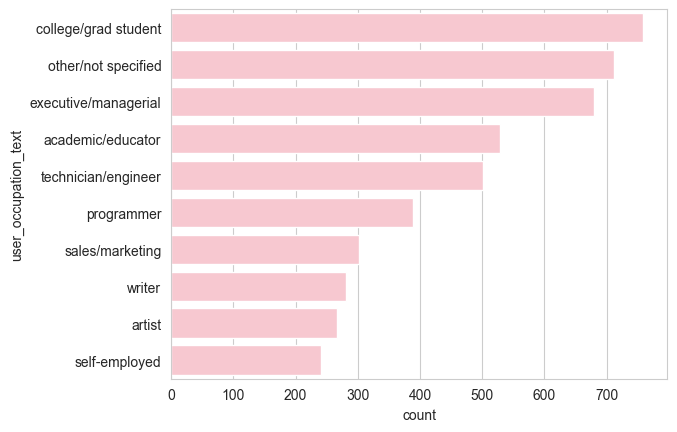

In [14]:
sns.countplot(
    y="user_occupation_text",
    data=users,
    order=users.user_occupation_text.value_counts().index[:10],
    color='pink'
)

популярность фильма (сколько людей оценили фильм)

In [15]:
movie_popularity = ratings.groupby("movie_id").size()
movies["rating_count"] = movies["movie_id"].map(movie_popularity)

movies["rating_count"]

0       869
1       256
2       218
3       210
4       487
       ... 
3701      1
3702      1
3703      1
3704      1
3705      1
Name: rating_count, Length: 3706, dtype: int64

средняя оценка фильма по всем пользователям

In [16]:
movie_mean = ratings.groupby("movie_id")["user_rating"].mean()
movies["mean_rating"] = movies["movie_id"].map(movie_mean)

movies["mean_rating"]

0       3.440736
1       3.687500
2       2.651376
3       1.852381
4       3.605749
          ...   
3701    3.000000
3702    3.000000
3703    3.000000
3704    3.000000
3705    3.000000
Name: mean_rating, Length: 3706, dtype: float64

год фильма

In [17]:
movies["year"] = movies["movie_title"].str.extract(r"\((\d{4})\)")
movies["year"] = movies["year"].astype(int)

movies["year"]

0       1991
1       1983
2       1994
3       1983
4       1977
        ... 
3701    1994
3702    1998
3703    1996
3704    1996
3705    1999
Name: year, Length: 3706, dtype: int64

У некоторых фильмов очень мало оценок, поэтому их средний рейтинг может быть нестабильным. Вместо удаления таких фильмов вводится параметр confidence, который отражает степень доверия к среднему рейтингу фильма в зависимости от количества полученных оценок но в логарифмической шкале что бы потом применить Bayesian rating

 (WR = (v ÷ (v+m)) × R + (m ÷ (v+m)) × C), где

WR = итоговый взвешенный рейтинг;

R = средняя оценка фильма (простое среднее арифметическое всех голосов);

v = количество голосов, отданных за фильм;

m = минимальное количество голосов, необходимое для включения в рейтинг (например, для списка Топ-250 по версии IMDb — 25 000 голосов);

C = средний рейтинг всех фильмов в базе данных (это значение меняется, но исторически колеблется в районе 7,0).

но без использования m (тк допустим новейшие фильмы не будут рекомендоваться)

In [18]:
movies["confidence"] = np.log1p(movies["rating_count"])
movies["confidence"] /= movies["confidence"].max()

C = ratings["user_rating"].mean()

movies["weighted_rating"] = (movies["confidence"] * movies["mean_rating"] + (1 - movies["confidence"]) * C)

корреляционная матрица

интересные закономерности:
1. mean_rating и user_rating 0.49, значит пользователи часто ставят оценки близкие к среднему рейтингу фильма
2. rating_count и mean_rating 0.52, значит популярные фильмы часто имеют более высокий средний рейтинг
3. year и mean_rating -0.32, значит новые фильмы имеют немного более низкие средние рейтинги

Отсюда же видно, что колонки с высокой корреляуцией стоит удалить (тк многие были задействованы в формуле для weighted_rating)

<Axes: >

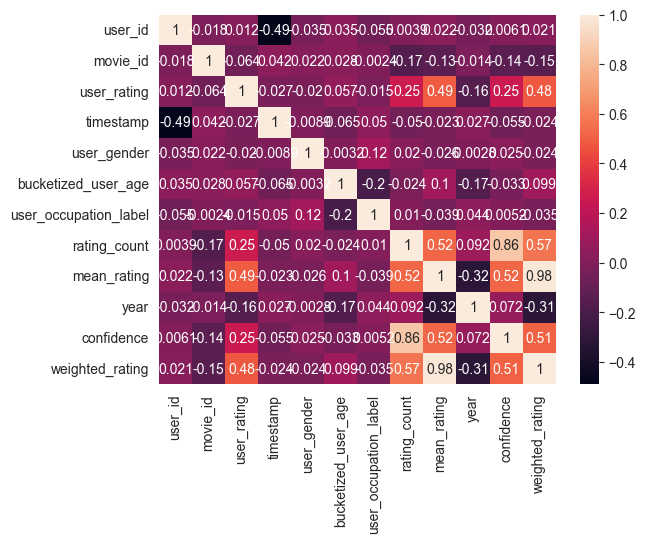

In [19]:
data = ratings.merge(users, on="user_id")
data = data.merge(movies, on="movie_id")
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True)

удаляем ненужные переменные

<Axes: >

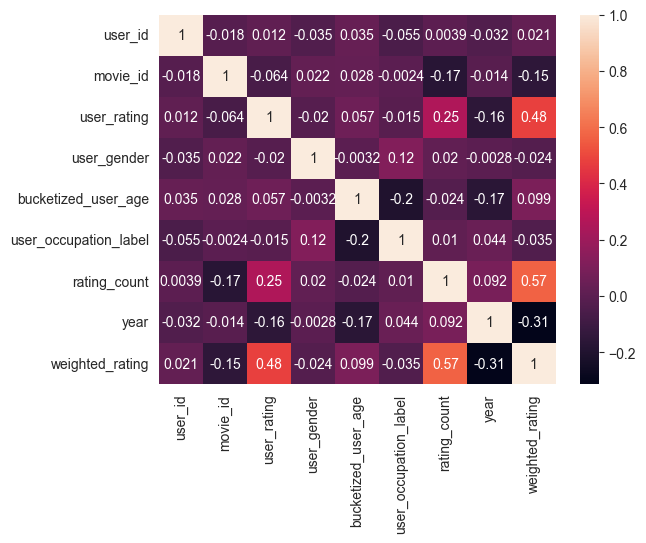

In [20]:
data = data.drop(columns=["mean_rating", "confidence", "timestamp"])
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True)

есть явно ненужные столбцы для модели:

1. user_occupation_text = дубликат occupation_label
2. user_zip_code = ненужно вообще
3. movie_title = для модели рекомендаций не нужно, только для выхода
4. poster_url = same
5. и лучше one-hot encodding по movie_genres, user_occupation_label и user_occupation_label

In [21]:
data.columns

Index(['user_id', 'movie_id', 'user_rating', 'user_gender',
       'bucketized_user_age', 'user_occupation_label', 'user_occupation_text',
       'user_zip_code', 'movie_title', 'movie_genres', 'poster_url',
       'rating_count', 'year', 'weighted_rating'],
      dtype='str')

удаляем ненужное и кодируем movie_genres

In [22]:
data_for_model = data.drop(columns=["user_occupation_text", "user_zip_code", "movie_title", "poster_url"])
data_for_model["movie_genres"] = data_for_model["movie_genres"].str.replace(r"\s+", "", regex=True)
genre_dummies = data_for_model["movie_genres"].str.get_dummies(",")
data_for_model = pd.concat([data_for_model.drop(columns=["movie_genres"]), genre_dummies], axis=1)
genre_cols = [c for c in data_for_model.columns if str(c).strip().isdigit()]
data_for_model.rename(columns={c: f"genre_{c.strip()}" for c in genre_cols}, inplace=True)

In [23]:
occupation_dummies = pd.get_dummies(data_for_model["user_occupation_label"], prefix="occ")
data_for_model = pd.concat([data_for_model, occupation_dummies], axis=1)
data_for_model = data_for_model.drop(columns=["user_occupation_label"])

In [24]:
age_dummies = pd.get_dummies(data_for_model["bucketized_user_age"], prefix="age")
data_for_model = pd.concat([data_for_model, age_dummies], axis=1)
data_for_model = data_for_model.drop(columns=["bucketized_user_age"])

In [25]:
bool_cols = data_for_model.select_dtypes(include="bool").columns
data_for_model[bool_cols] = data_for_model[bool_cols].astype(int)

In [26]:
data_for_model.head(10)

,user_id,movie_id,user_rating,user_gender,rating_count,year,weighted_rating,genre_0,genre_1,genre_10,...,occ_19,occ_20,occ_21,age_1.0,age_18.0,age_25.0,age_35.0,age_45.0,age_50.0,age_56.0
0,130,3107,5.0,1,869,1991,3.464465,1,0,0,...,0,0,0,0,0,0,1,0,0,0
1,3829,2114,4.0,0,256,1983,3.653781,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,1265,256,1.0,0,218,1994,2.965737,0,0,0,...,0,0,1,0,1,0,0,0,0,0
3,2896,1389,5.0,1,210,1983,2.444670,1,0,1,...,0,0,0,0,1,0,0,0,0,0
4,5264,3635,4.0,1,487,1977,3.599957,1,0,0,...,0,0,0,0,1,0,0,0,0,0
5,4957,2042,2.0,1,193,1994,2.967129,0,0,0,...,0,0,0,0,0,1,0,0,0,0
6,5294,2289,4.0,1,978,1992,3.904423,0,0,0,...,0,0,0,0,0,1,0,0,0,0
7,2064,3334,5.0,1,461,1948,3.959093,0,0,0,...,0,0,0,0,0,0,1,0,0,0
8,4121,2901,3.0,1,330,1979,3.311750,0,0,1,...,0,0,0,0,0,0,0,1,0,0
9,3010,1206,4.0,1,1229,1971,4.015571,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [27]:
data_for_model.shape

(1000209, 52)

#### modeling

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupKFold

In [29]:
train_list = []
test_list = []

for user_id, group in data_for_model.groupby("user_id"):

    train_u, test_u = train_test_split(
        group,
        test_size=0.2,
        random_state=42
    )

    train_list.append(train_u)
    test_list.append(test_u)

train = pd.concat(train_list)
test = pd.concat(test_list)

In [30]:
X_train = train.drop(columns=["user_rating","user_id","movie_id"])
y_train = train["user_rating"]

X_test = test.drop(columns=["user_rating","user_id","movie_id"])
y_test = test["user_rating"]

In [31]:
# gkf = GroupKFold(n_splits=5)

# for train_idx, val_idx in gkf.split(X_train, y_train, groups=train["user_id"]):
#     X_tr = X_train.iloc[train_idx]
#     X_val = X_train.iloc[val_idx]

#     y_tr = y_train.iloc[train_idx]
#     y_val = y_train.iloc[val_idx]